In [ ]:
!pip install --no-cache-dir pillow sentencepiece --quiet
!pip install --no-cache-dir transformers==4.44.2 --quiet
!pip install sentence-transformers opencv-python-headless torch pandas pdfplumber --quiet

In [ ]:
import cv2
import numpy as np
from PIL import Image
import torch
import re
import pandas as pd
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from sentence_transformers import SentenceTransformer, util
import pdfplumber
from google.colab import files

In [ ]:
print("Upload the student's handwritten answer sheet (image)")
uploaded_sheet = files.upload()
sheet_path = list(uploaded_sheet.keys())[0]
print("Uploaded:", sheet_path)

Upload the student's handwritten answer sheet (image)


Saving student_answer_sheet.png to student_answer_sheet.png
Uploaded: student_answer_sheet.png


In [ ]:
print("Upload the question paper PDF")
uploaded_qp = files.upload()
qp_path = list(uploaded_qp.keys())[0]
print("Uploaded:", qp_path)

Upload the question paper PDF


Saving question_paper.pdf to question_paper.pdf
Uploaded: question_paper.pdf


In [ ]:
print("Upload the reference/model answer sheet PDF")
uploaded_ref = files.upload()
ref_pdf_path = list(uploaded_ref.keys())[0]
print("Uploaded:", ref_pdf_path)

Upload the reference/model answer sheet PDF


Saving reference_answers.pdf to reference_answers.pdf
Uploaded: reference_answers.pdf


In [ ]:
def extract_pdf_text(pdf_path):
    full_text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                full_text += page_text + "\n"
    return full_text.strip()

In [ ]:
qp_text = extract_pdf_text(qp_path)

def extract_marks_from_qp(text):
    pattern = r"(?:Q)?(\d+)[\.\)]\s*(.*?)\s*[\[\(](\d+)\s*(?:marks|mark|m)?[\]\)]"
    matches = re.findall(pattern, text, re.IGNORECASE | re.DOTALL)
    records = []
    for qnum, qtext, marks in matches:
        records.append({
            "question_no": qnum.strip(),
            "question_text": qtext.strip(),
            "max_marks": int(marks)
        })
    return pd.DataFrame(records)

marks_df = extract_marks_from_qp(qp_text)
print(f"Extracted {len(marks_df)} questions")
marks_df

Extracted 4 questions


,question_no,question_text,max_marks
0,1,What is photosynthesis?,5
1,2,State Newton's second law of motion.,5
2,3,What is the powerhouse of the cell?,5
3,4,Define Ohm's Law.,5


In [ ]:
ref_text = extract_pdf_text(ref_pdf_path)

def split_by_question(text, question_numbers):
    pattern = r"(?:Q)?(" + "|".join(question_numbers) + r")[\.\)]\s*"
    parts = re.split(pattern, text)
    answers = {}
    i = 1
    while i < len(parts) - 1:
        qnum = parts[i].strip()
        ans_text = parts[i+1].strip()
        answers[qnum] = ans_text
        i += 2
    return answers

question_numbers = marks_df["question_no"].tolist()
reference_answers = split_by_question(ref_text, question_numbers)
reference_answers

{'1': 'Photosynthesis is the process by which green plants use sunlight, water, and carbon dioxide to\nproduce glucose and oxygen.',
 '2': "Newton's second law states that the force acting on an object is equal to the mass of the object\nmultiplied by its acceleration, F=ma.",
 '3': 'The mitochondria is known as the powerhouse of the cell because it produces energy in the form of\nATP.',
 '4': "Ohm's Law states that the current through a conductor is directly proportional to the voltage across it,\nprovided temperature remains constant, V=IR."}

Detected 10 lines


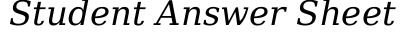

In [ ]:
def preprocess_image(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Adaptive threshold handles uneven lighting/shadows in real phone photos
    adaptive = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, blockSize=35, C=15
    )

    # Merge letters within a line into solid blobs (cleaner line boundaries)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 3))
    closed = cv2.morphologyEx(adaptive, cv2.MORPH_CLOSE, kernel)

    return closed, adaptive, img

def segment_lines(closed_img, raw_binary_img, original_img):
    row_sums = np.sum(closed_img, axis=1)
    row_threshold = row_sums.max() * 0.1

    in_line = False
    line_boxes = []
    start = 0
    for i, val in enumerate(row_sums):
        if val > row_threshold and not in_line:
            in_line = True
            start = i
        elif val <= row_threshold and in_line:
            in_line = False
            end = i
            if end - start > 15:
                line_boxes.append((start, end))
    if in_line:
        line_boxes.append((start, len(row_sums)))

    line_images = []
    h, w = closed_img.shape
    for (y1, y2) in line_boxes:
        pad = 6
        y1p = max(0, y1 - pad)
        y2p = min(h, y2 + pad)

        band = raw_binary_img[y1p:y2p, :]
        col_sums = np.sum(band, axis=0)
        text_cols = np.where(col_sums > 0)[0]
        if len(text_cols) == 0:
            continue
        x1 = max(0, text_cols[0] - 10)
        x2 = min(w, text_cols[-1] + 10)

        crop = original_img[y1p:y2p, x1:x2]
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        line_images.append(Image.fromarray(crop_rgb))

    return line_images

closed_img, raw_binary_img, original_img = preprocess_image(sheet_path)
line_images = segment_lines(closed_img, raw_binary_img, original_img)
print(f"Detected {len(line_images)} lines")
line_images[0]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
ocr_processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
ocr_model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten").to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
import re

def clean_ocr_line(text):
    # Strip trailing runs of digits/symbols/spaces that TrOCR hallucinates
    text = re.sub(r'[\d\s/\.\-,()]{3,}$', '', text).strip()
    return text

line_texts = []
for i, line_img in enumerate(line_images):
    pixel_values = ocr_processor(images=line_img, return_tensors="pt").pixel_values.to(device)
    generated_ids = ocr_model.generate(
        pixel_values,
        max_length=60,
        num_beams=4,
        early_stopping=True,
        repetition_penalty=2.5,
        no_repeat_ngram_size=3
    )
    text = ocr_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    text = clean_ocr_line(text)
    line_texts.append(text)
    print(f"Line {i}: {text}")

full_text = "\n".join(line_texts)
print("\n---- FULL RECONSTRUCTED TEXT ----")
print(full_text)

Line 0: Student Answer Sheet
Line 1: Name : A. Student Roll No
Line 2: 1. Photosynthesis is when plants use sunlight and water
Line 3: to make their own food and release oxygen.
Line 4: 2. Newtons second law says force is mass into
Line 5: acceleration, F is equal to m times a.
Line 6: 3. Mitochondria is called the powerhouse of the cell as
Line 7: it makes energy for the cell.
Line 8: 4. Ohms law tells us voltage equals current times
Line 9: resistance, VOIR, at constant temperature.

---- FULL RECONSTRUCTED TEXT ----
Student Answer Sheet
Name : A. Student Roll No
1. Photosynthesis is when plants use sunlight and water
to make their own food and release oxygen.
2. Newtons second law says force is mass into
acceleration, F is equal to m times a.
3. Mitochondria is called the powerhouse of the cell as
it makes energy for the cell.
4. Ohms law tells us voltage equals current times
resistance, VOIR, at constant temperature.


In [ ]:
student_answers = split_by_question(full_text, question_numbers)
student_answers

{'1': 'Photosynthesis is when plants use sunlight and water\nto make their own food and release oxygen.',
 '2': 'Newtons second law says force is mass into\nacceleration, F is equal to m times a.',
 '3': 'Mitochondria is called the powerhouse of the cell as\nit makes energy for the cell.',
 '4': 'Ohms law tells us voltage equals current times\nresistance, VOIR, at constant temperature.'}

In [ ]:
grading_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

def semantic_score(student_answer, reference_answer):
    emb1 = grading_model.encode(student_answer, convert_to_tensor=True)
    emb2 = grading_model.encode(reference_answer, convert_to_tensor=True)
    return util.cos_sim(emb1, emb2).item()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def similarity_to_marks(sim_score, max_marks):
    if sim_score < 0.5:
        return 0
    elif sim_score >= 0.88:
        return max_marks
    else:
        # steeper penalty in the middle range
        return round(((sim_score - 0.5) / (0.88 - 0.5)) * max_marks, 1)

In [ ]:
results = []

for _, row in marks_df.iterrows():
    qnum = row["question_no"]
    max_marks = row["max_marks"]

    reference = reference_answers.get(qnum, "")
    student_ans = student_answers.get(qnum, "")

    if student_ans == "" or reference == "":
        sim = 0
        marks = 0
    else:
        sim = semantic_score(student_ans, reference)
        marks = similarity_to_marks(sim, max_marks)

    results.append({
        "question_no": qnum,
        "student_answer": student_ans,
        "reference_answer": reference,
        "similarity": round(sim, 3) if student_ans and reference else 0,
        "marks_awarded": marks,
        "max_marks": max_marks
    })

df = pd.DataFrame(results)
df

,question_no,student_answer,reference_answer,similarity,marks_awarded,max_marks
0,1,Photosynthesis is when plants use sunlight and...,Photosynthesis is the process by which green p...,0.881,5.0,5
1,2,Newtons second law says force is mass into\nac...,Newton's second law states that the force acti...,0.888,5.0,5
2,3,Mitochondria is called the powerhouse of the c...,The mitochondria is known as the powerhouse of...,0.951,5.0,5
3,4,Ohms law tells us voltage equals current times...,Ohm's Law states that the current through a co...,0.726,3.0,5


In [ ]:
total_awarded = df["marks_awarded"].sum()
total_max = df["max_marks"].sum()
print(f"Total Score: {total_awarded} / {total_max}")

df.to_csv("grading_report.csv", index=False)
files.download("grading_report.csv")

Total Score: 18.0 / 20


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>